# 第14章: マルコフ連鎖

## 学習目標
- マルコフ連鎖の定義と遷移行列を理解する
- チャップマン・コルモゴロフ方程式を適用できる
- 定常分布を計算できる
- エルゴード定理を理解する
- 状態の分類（再帰的、過渡的、吸収的）ができる

## 📋 学習メタ情報

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
import seaborn as sns
import networkx as nx

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 14.1 マルコフ連鎖の定義

### マルコフ性
確率過程 $\{X_n\}$ がマルコフ性を持つとは、次の条件を満たすことである:
$$P(X_{n+1} = j | X_n = i, X_{n-1} = i_{n-1}, \ldots, X_0 = i_0) = P(X_{n+1} = j | X_n = i)$$

つまり、将来の状態は現在の状態のみに依存し、過去の履歴には依存しない。

### 遷移確率
$$p_{ij} = P(X_{n+1} = j | X_n = i)$$

### 遷移行列
$$P = \begin{pmatrix} p_{11} & p_{12} & \cdots & p_{1m} \\ p_{21} & p_{22} & \cdots & p_{2m} \\ \vdots & \vdots & \ddots & \vdots \\ p_{m1} & p_{m2} & \cdots & p_{mm} \end{pmatrix}$$

各行の和は1: $\sum_{j=1}^{m} p_{ij} = 1$

天気のマルコフ連鎖

遷移行列 P:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]

各行の和: [1. 1. 1.]


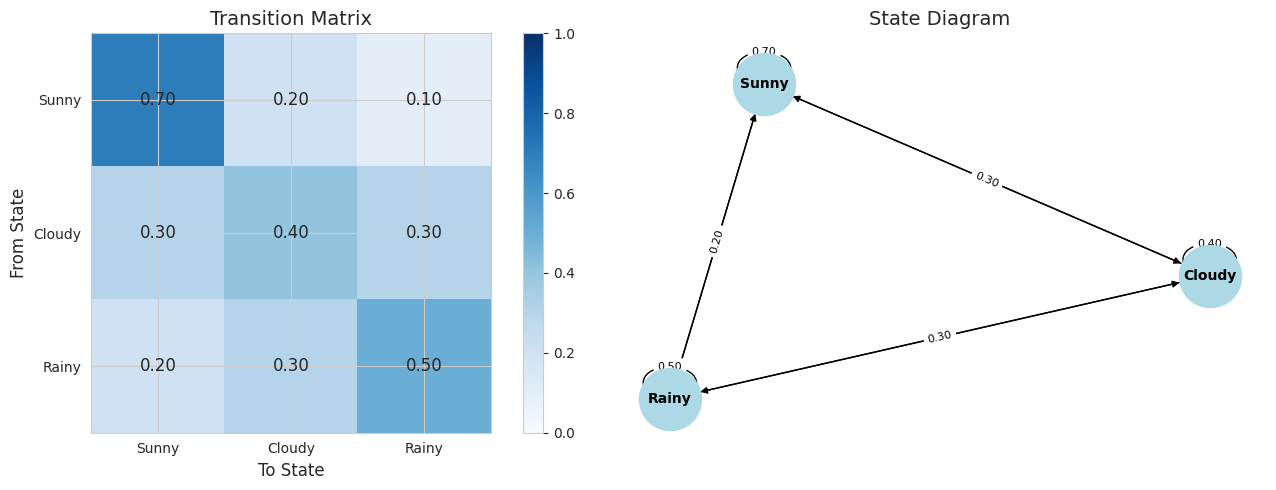

In [2]:
# 天気のマルコフ連鎖モデル
# States: 0 = Sunny, 1 = Cloudy, 2 = Rainy

# Transition matrix
P = np.array([
    [0.7, 0.2, 0.1],  # From Sunny
    [0.3, 0.4, 0.3],  # From Cloudy
    [0.2, 0.3, 0.5]   # From Rainy
])

states = ['Sunny', 'Cloudy', 'Rainy']

print("天気のマルコフ連鎖")
print("="*50)
print("\n遷移行列 P:")
print(P)
print(f"\n各行の和: {P.sum(axis=1)}")

# Visualize transition matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(P, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(states)
axes[0].set_yticklabels(states)
axes[0].set_xlabel('To State', fontsize=12)
axes[0].set_ylabel('From State', fontsize=12)
axes[0].set_title('Transition Matrix', fontsize=14)

# Add values
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{P[i,j]:.2f}', ha='center', va='center', fontsize=12)

plt.colorbar(im, ax=axes[0])

# State diagram
G = nx.DiGraph()
for i, s in enumerate(states):
    G.add_node(s)

for i in range(3):
    for j in range(3):
        if P[i,j] > 0:
            G.add_edge(states[i], states[j], weight=P[i,j])

pos = nx.spring_layout(G, k=2)
nx.draw(G, pos, ax=axes[1], with_labels=True, node_color='lightblue', 
        node_size=2000, font_size=10, font_weight='bold', arrows=True)

edge_labels = {(states[i], states[j]): f'{P[i,j]:.2f}' 
               for i in range(3) for j in range(3) if P[i,j] > 0}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=axes[1], font_size=8)
axes[1].set_title('State Diagram', fontsize=14)

plt.tight_layout()
plt.show()

マルコフ連鎖シミュレーション (100日間)

初期状態: Sunny

状態の頻度:
  Sunny: 0.525
  Cloudy: 0.248
  Rainy: 0.228


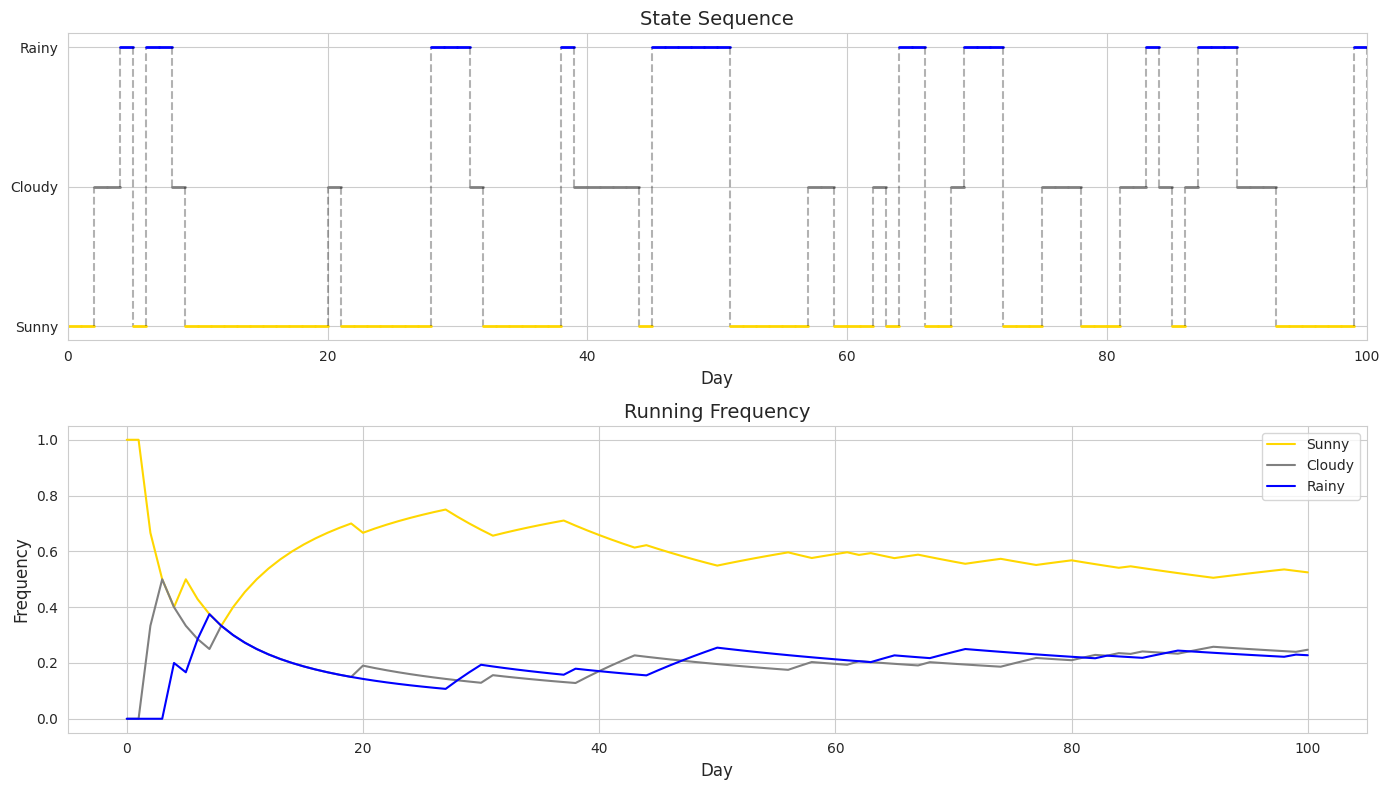

In [3]:
# マルコフ連鎖のシミュレーション
def simulate_markov_chain(P, initial_state, n_steps):
    """Simulate a Markov chain."""
    n_states = len(P)
    states_sequence = [initial_state]
    current_state = initial_state
    
    for _ in range(n_steps):
        next_state = np.random.choice(n_states, p=P[current_state])
        states_sequence.append(next_state)
        current_state = next_state
    
    return np.array(states_sequence)

# Simulate 100 days starting from Sunny
n_steps = 100
sequence = simulate_markov_chain(P, 0, n_steps)

# Count state frequencies
counts = [np.sum(sequence == i) / len(sequence) for i in range(3)]

print("マルコフ連鎖シミュレーション (100日間)")
print("="*50)
print(f"\n初期状態: Sunny")
print(f"\n状態の頻度:")
for i, s in enumerate(states):
    print(f"  {s}: {counts[i]:.3f}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# State sequence
colors = ['gold', 'gray', 'blue']
for i in range(len(sequence)-1):
    axes[0].plot([i, i+1], [sequence[i], sequence[i]], color=colors[sequence[i]], linewidth=2)
    if sequence[i] != sequence[i+1]:
        axes[0].plot([i+1, i+1], [sequence[i], sequence[i+1]], 'k--', alpha=0.3)

axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(states)
axes[0].set_xlabel('Day', fontsize=12)
axes[0].set_title('State Sequence', fontsize=14)
axes[0].set_xlim(0, n_steps)

# Running frequency
running_freq = np.zeros((n_steps+1, 3))
for t in range(1, n_steps+2):
    for s in range(3):
        running_freq[t-1, s] = np.sum(sequence[:t] == s) / t

for i, s in enumerate(states):
    axes[1].plot(running_freq[:, i], label=s, color=colors[i])

axes[1].set_xlabel('Day', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Running Frequency', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 14.2 チャップマン・コルモゴロフ方程式

### n段階遷移確率
$$p_{ij}^{(n)} = P(X_n = j | X_0 = i)$$

### チャップマン・コルモゴロフ方程式
$$p_{ij}^{(m+n)} = \sum_{k} p_{ik}^{(m)} p_{kj}^{(n)}$$

行列形式:
$$P^{(m+n)} = P^{(m)} \cdot P^{(n)}$$

特に:
$$P^{(n)} = P^n$$

In [4]:
# n段階遷移確率の計算
print("n段階遷移確率")
print("="*50)

# Calculate P^n for various n
for n in [1, 2, 5, 10, 50]:
    Pn = np.linalg.matrix_power(P, n)
    print(f"\nP^{n}:")
    print(np.round(Pn, 4))

# Verify Chapman-Kolmogorov
print("\nチャップマン・コルモゴロフ方程式の検証")
print("-"*50)

P2 = np.linalg.matrix_power(P, 2)
P3 = np.linalg.matrix_power(P, 3)
P5 = np.linalg.matrix_power(P, 5)

# P^5 = P^2 * P^3
P5_verify = P2 @ P3

print(f"\nP^5 (直接計算):")
print(np.round(P5, 4))
print(f"\nP^2 * P^3:")
print(np.round(P5_verify, 4))
print(f"\n差の最大値: {np.max(np.abs(P5 - P5_verify)):.2e}")

n段階遷移確率

P^1:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]

P^2:
[[0.57 0.25 0.18]
 [0.39 0.31 0.3 ]
 [0.33 0.31 0.36]]

P^5:
[[0.4685 0.2794 0.2521]
 [0.4498 0.2844 0.2658]
 [0.4429 0.2862 0.2708]]

P^10:
[[0.4568 0.2825 0.2607]
 [0.4564 0.2827 0.261 ]
 [0.4562 0.2827 0.2611]]

P^50:
[[0.4565 0.2826 0.2609]
 [0.4565 0.2826 0.2609]
 [0.4565 0.2826 0.2609]]

チャップマン・コルモゴロフ方程式の検証
--------------------------------------------------

P^5 (直接計算):
[[0.4685 0.2794 0.2521]
 [0.4498 0.2844 0.2658]
 [0.4429 0.2862 0.2708]]

P^2 * P^3:
[[0.4685 0.2794 0.2521]
 [0.4498 0.2844 0.2658]
 [0.4429 0.2862 0.2708]]

差の最大値: 5.55e-17


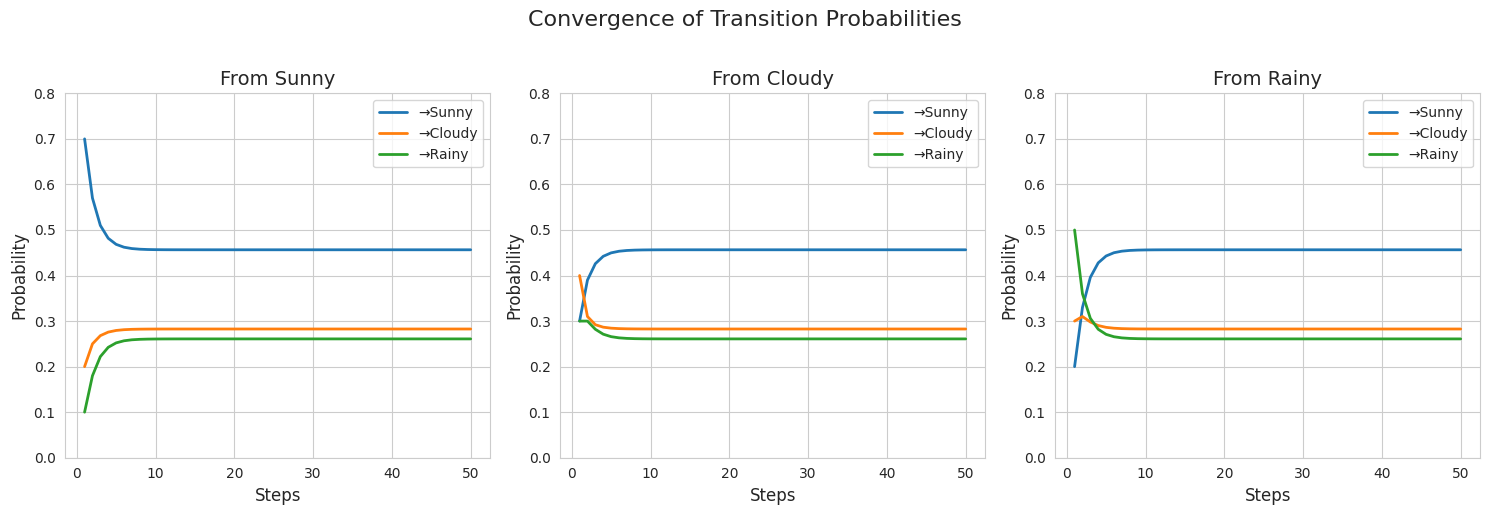

In [5]:
# 遷移確率の収束
n_steps = 50
prob_evolution = np.zeros((n_steps, 3, 3))

for n in range(n_steps):
    prob_evolution[n] = np.linalg.matrix_power(P, n+1)

# Plot convergence from each initial state
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, initial in enumerate(states):
    for j, final in enumerate(states):
        axes[i].plot(range(1, n_steps+1), prob_evolution[:, i, j], 
                     label=f'→{final}', linewidth=2)
    axes[i].set_xlabel('Steps', fontsize=12)
    axes[i].set_ylabel('Probability', fontsize=12)
    axes[i].set_title(f'From {initial}', fontsize=14)
    axes[i].legend()
    axes[i].set_ylim(0, 0.8)

plt.suptitle('Convergence of Transition Probabilities', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 14.3 定常分布

### 定義
確率分布 $\pi = (\pi_1, \pi_2, \ldots, \pi_m)$ が定常分布であるとは:
$$\pi P = \pi$$
$$\sum_i \pi_i = 1, \quad \pi_i \geq 0$$

### 計算方法
固有値問題: $\pi$ は遷移行列 $P^T$ の固有値1に対応する固有ベクトル

または連立方程式:
$$\begin{cases} \pi_1 p_{11} + \pi_2 p_{21} + \cdots + \pi_m p_{m1} = \pi_1 \\ \pi_1 p_{12} + \pi_2 p_{22} + \cdots + \pi_m p_{m2} = \pi_2 \\ \vdots \\ \pi_1 + \pi_2 + \cdots + \pi_m = 1 \end{cases}$$

In [6]:
# 定常分布の計算
print("定常分布の計算")
print("="*50)

# Method 1: Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(P.T)

# Find eigenvector corresponding to eigenvalue 1
idx = np.argmin(np.abs(eigenvalues - 1))
stationary = np.real(eigenvectors[:, idx])
stationary = stationary / stationary.sum()  # Normalize

print("\n方法1: 固有値分解")
print(f"固有値: {np.round(eigenvalues, 4)}")
print(f"定常分布: {np.round(stationary, 4)}")

# Method 2: Solve linear system
# (P^T - I)π = 0 with constraint sum(π) = 1
n = len(P)
A = np.vstack([P.T - np.eye(n), np.ones(n)])
b = np.zeros(n+1)
b[-1] = 1

stationary2 = np.linalg.lstsq(A, b, rcond=None)[0]

print("\n方法2: 連立方程式")
print(f"定常分布: {np.round(stationary2, 4)}")

# Method 3: Power iteration (limit of P^n)
P_inf = np.linalg.matrix_power(P, 1000)
stationary3 = P_inf[0]  # Any row should be the stationary distribution

print("\n方法3: 累乗の極限")
print(f"定常分布: {np.round(stationary3, 4)}")

# Verify: π * P = π
print("\n検証: π * P = π")
print(f"π * P = {np.round(stationary @ P, 4)}")
print(f"π     = {np.round(stationary, 4)}")

定常分布の計算

方法1: 固有値分解
固有値: [1.     0.4732 0.1268]
定常分布: [0.4565 0.2826 0.2609]

方法2: 連立方程式
定常分布: [0.4565 0.2826 0.2609]

方法3: 累乗の極限
定常分布: [0.4565 0.2826 0.2609]

検証: π * P = π
π * P = [0.4565 0.2826 0.2609]
π     = [0.4565 0.2826 0.2609]


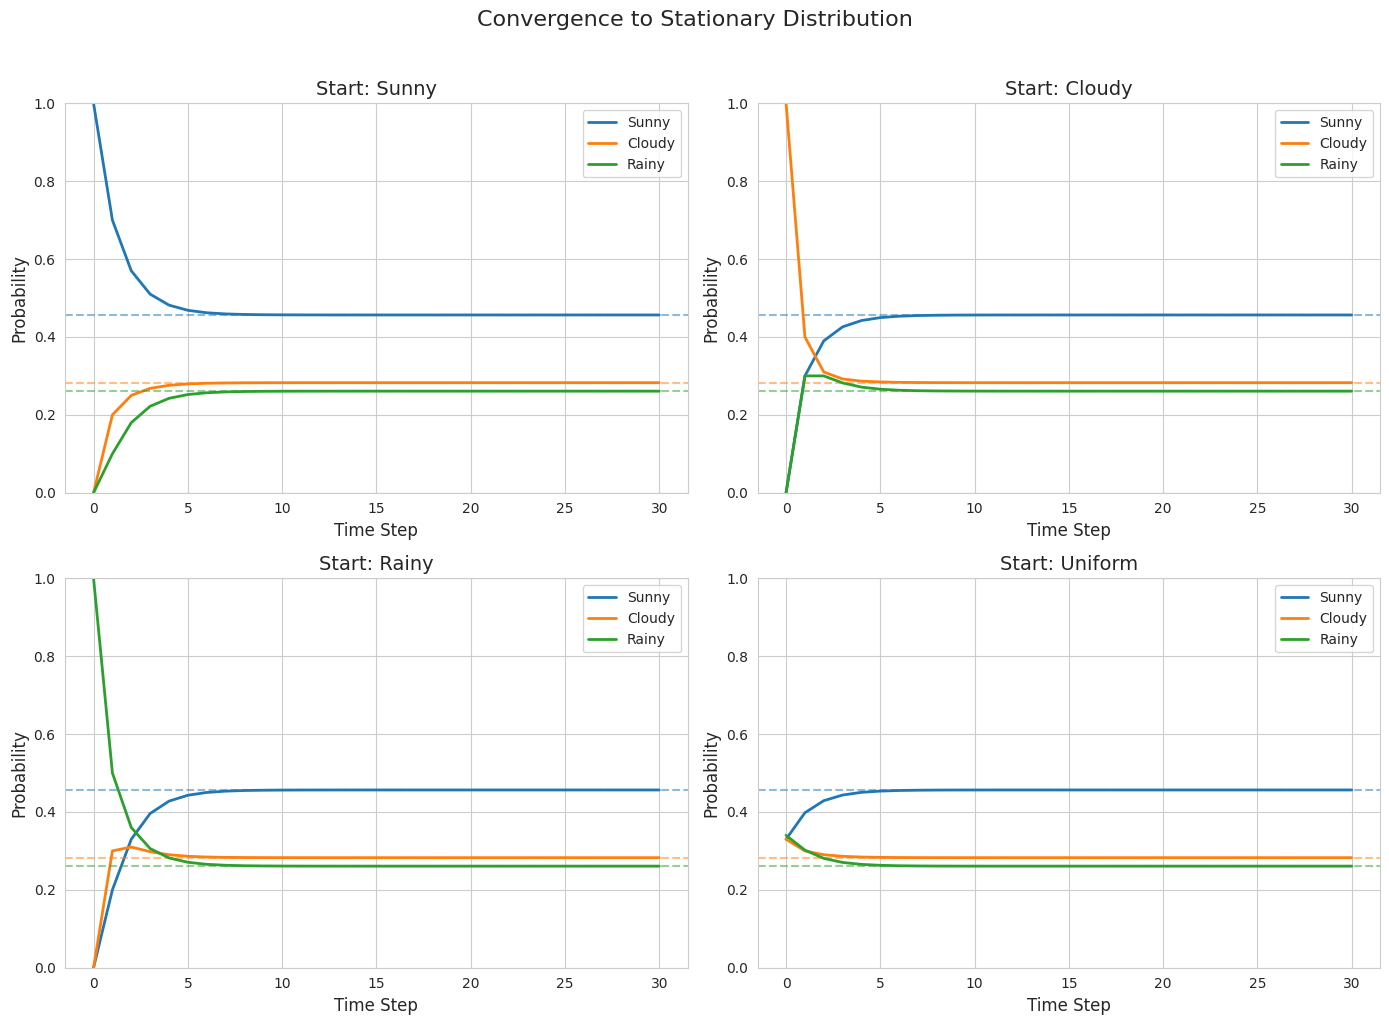

In [7]:
# 定常分布への収束のシミュレーション
np.random.seed(123)

# Start from different initial distributions
initial_dists = [
    np.array([1, 0, 0]),  # Start from Sunny
    np.array([0, 1, 0]),  # Start from Cloudy
    np.array([0, 0, 1]),  # Start from Rainy
    np.array([0.33, 0.33, 0.34])  # Uniform
]

n_steps = 30

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

labels = ['Start: Sunny', 'Start: Cloudy', 'Start: Rainy', 'Start: Uniform']

for idx, init_dist in enumerate(initial_dists):
    dist_evolution = np.zeros((n_steps+1, 3))
    dist_evolution[0] = init_dist
    
    for t in range(n_steps):
        dist_evolution[t+1] = dist_evolution[t] @ P
    
    for i, s in enumerate(states):
        axes[idx].plot(dist_evolution[:, i], label=s, linewidth=2)
        axes[idx].axhline(stationary[i], color=f'C{i}', linestyle='--', alpha=0.5)
    
    axes[idx].set_xlabel('Time Step', fontsize=12)
    axes[idx].set_ylabel('Probability', fontsize=12)
    axes[idx].set_title(labels[idx], fontsize=14)
    axes[idx].legend()
    axes[idx].set_ylim(0, 1)

plt.suptitle('Convergence to Stationary Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 14.4 エルゴード定理

### 既約性
全ての状態対 $(i, j)$ について、ある $n > 0$ が存在して $p_{ij}^{(n)} > 0$ となるとき、マルコフ連鎖は既約である。

### 非周期性
状態 $i$ の周期 $d_i$ が1のとき、非周期的という:
$$d_i = \gcd\{n > 0 : p_{ii}^{(n)} > 0\}$$

### エルゴード定理
既約で非周期的なマルコフ連鎖について、初期分布によらず:
$$\lim_{n \to \infty} p_{ij}^{(n)} = \pi_j$$

また、時間平均は定常分布に収束:
$$\lim_{n \to \infty} \frac{1}{n} \sum_{k=1}^{n} \mathbf{1}_{\{X_k = j\}} = \pi_j \quad \text{(確率1で)}$$

エルゴード定理の検証

シミュレーション数: 100
各シミュレーションのステップ数: 10000

State             理論値         時間平均         標準偏差
--------------------------------------------------
Sunny          0.4565       0.4548       0.0086
Cloudy         0.2826       0.2828       0.0051
Rainy          0.2609       0.2624       0.0071


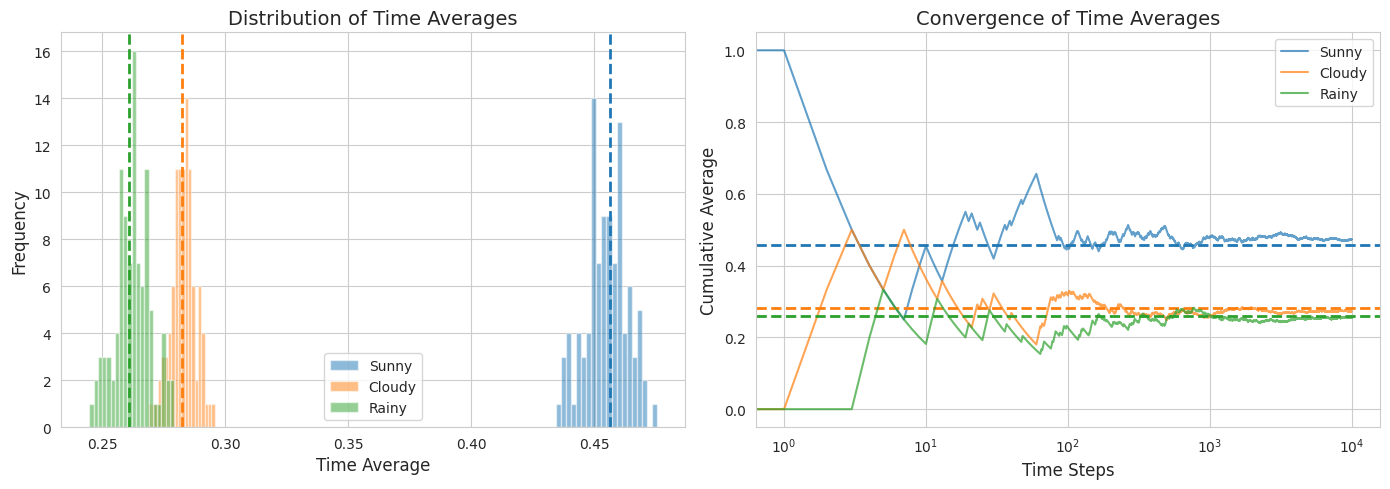

In [8]:
# エルゴード定理の検証
np.random.seed(456)

# Long simulation
n_steps = 10000
n_simulations = 100

# Track time averages
time_averages = np.zeros((n_simulations, 3))

for sim in range(n_simulations):
    # Random initial state
    initial = np.random.randint(0, 3)
    sequence = simulate_markov_chain(P, initial, n_steps)
    
    for s in range(3):
        time_averages[sim, s] = np.mean(sequence == s)

print("エルゴード定理の検証")
print("="*50)
print(f"\nシミュレーション数: {n_simulations}")
print(f"各シミュレーションのステップ数: {n_steps}")
print(f"\n{'State':<10} {'理論値':>10} {'時間平均':>12} {'標準偏差':>12}")
print("-"*50)
for i, s in enumerate(states):
    print(f"{s:<10} {stationary[i]:>10.4f} {time_averages[:, i].mean():>12.4f} {time_averages[:, i].std():>12.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of time averages
for i, s in enumerate(states):
    axes[0].hist(time_averages[:, i], bins=20, alpha=0.5, label=s)
    axes[0].axvline(stationary[i], color=f'C{i}', linestyle='--', linewidth=2)

axes[0].set_xlabel('Time Average', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Time Averages', fontsize=14)
axes[0].legend()

# Convergence of one simulation
sequence = simulate_markov_chain(P, 0, n_steps)
cumulative_avg = np.zeros((n_steps+1, 3))
for t in range(1, n_steps+2):
    for s in range(3):
        cumulative_avg[t-1, s] = np.mean(sequence[:t] == s)

for i, s in enumerate(states):
    axes[1].plot(cumulative_avg[:, i], label=s, alpha=0.7)
    axes[1].axhline(stationary[i], color=f'C{i}', linestyle='--', linewidth=2)

axes[1].set_xlabel('Time Steps', fontsize=12)
axes[1].set_ylabel('Cumulative Average', fontsize=12)
axes[1].set_title('Convergence of Time Averages', fontsize=14)
axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## 14.5 状態の分類

### 到達可能性
状態 $j$ が状態 $i$ から到達可能: $i \to j$ ⟺ ある $n \geq 0$ で $p_{ij}^{(n)} > 0$

### 連絡可能性
$i \leftrightarrow j$ ⟺ $i \to j$ かつ $j \to i$

### 再帰的状態と過渡的状態
- **再帰的 (Recurrent)**: 状態に一度入ると確率1で戻る
  $$f_{ii} = P(\text{return to } i | X_0 = i) = 1$$
  
- **過渡的 (Transient)**: 戻らない確率が正
  $$f_{ii} < 1$$

### 吸収状態
$$p_{ii} = 1$$

一度入ると出られない状態

ギャンブラーの破産問題

勝率: 0.4
状態: 0 (破産) から 5 (目標達成)

遷移行列:
[[1.  0.  0.  0.  0.  0. ]
 [0.6 0.  0.4 0.  0.  0. ]
 [0.  0.6 0.  0.4 0.  0. ]
 [0.  0.  0.6 0.  0.4 0. ]
 [0.  0.  0.  0.6 0.  0.4]
 [0.  0.  0.  0.  0.  1. ]]


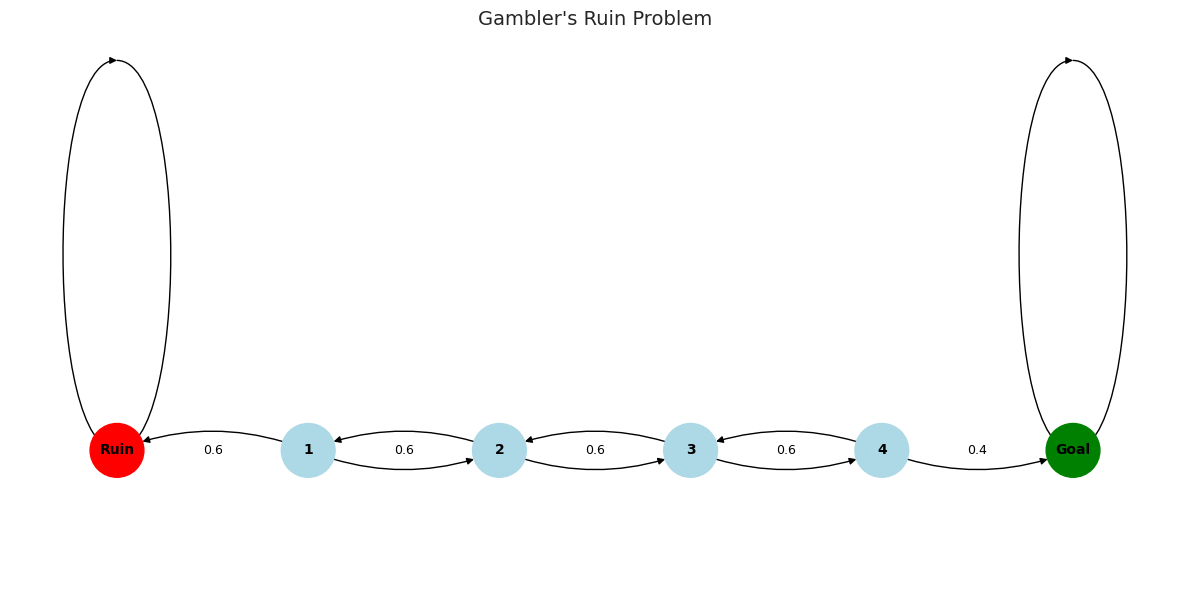

In [9]:
# 吸収状態を持つマルコフ連鎖
# ギャンブラーの破産問題

# States: 0 (破産), 1, 2, 3, 4, 5 (目標達成)
# Win probability p = 0.4

p_win = 0.4
n_states = 6

P_gambler = np.zeros((n_states, n_states))
P_gambler[0, 0] = 1  # Absorbing state (ruin)
P_gambler[5, 5] = 1  # Absorbing state (goal)

for i in range(1, 5):
    P_gambler[i, i+1] = p_win      # Win
    P_gambler[i, i-1] = 1 - p_win  # Lose

print("ギャンブラーの破産問題")
print("="*50)
print(f"\n勝率: {p_win}")
print(f"状態: 0 (破産) から 5 (目標達成)")
print("\n遷移行列:")
print(P_gambler)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

G = nx.DiGraph()
state_names = ['Ruin', '1', '2', '3', '4', 'Goal']

for i in range(n_states):
    for j in range(n_states):
        if P_gambler[i, j] > 0:
            G.add_edge(state_names[i], state_names[j], weight=P_gambler[i, j])

pos = {state_names[i]: (i, 0) for i in range(n_states)}
node_colors = ['red' if i == 0 else 'green' if i == 5 else 'lightblue' for i in range(n_states)]

nx.draw(G, pos, ax=ax, with_labels=True, node_color=node_colors, 
        node_size=1500, font_size=10, font_weight='bold', arrows=True,
        connectionstyle='arc3,rad=0.2')

edge_labels = {(state_names[i], state_names[j]): f'{P_gambler[i,j]:.1f}' 
               for i in range(n_states) for j in range(n_states) if P_gambler[i,j] > 0 and i != j}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=9)

ax.set_title("Gambler's Ruin Problem", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# 吸収確率の計算
# Q: transient to transient transitions
# R: transient to absorbing transitions

# Reorder states: transient (1,2,3,4), absorbing (0,5)
Q = P_gambler[1:5, 1:5]
R = np.column_stack([P_gambler[1:5, 0], P_gambler[1:5, 5]])

print("吸収マルコフ連鎖の分析")
print("="*50)
print("\nQ (過渡→過渡):")
print(Q)
print("\nR (過渡→吸収):")
print(R)

# Fundamental matrix
N = np.linalg.inv(np.eye(4) - Q)
print("\n基本行列 N = (I-Q)^(-1):")
print(np.round(N, 4))

# Expected number of steps before absorption
t = N.sum(axis=1)
print("\n吸収までの期待ステップ数:")
for i, steps in enumerate(t):
    print(f"  状態 {i+1} から: {steps:.2f}")

# Absorption probabilities
B = N @ R
print("\n吸収確率 (破産, 目標達成):")
for i, probs in enumerate(B):
    print(f"  状態 {i+1} から: [{probs[0]:.4f}, {probs[1]:.4f}]")

吸収マルコフ連鎖の分析

Q (過渡→過渡):
[[0.  0.4 0.  0. ]
 [0.6 0.  0.4 0. ]
 [0.  0.6 0.  0.4]
 [0.  0.  0.6 0. ]]

R (過渡→吸収):
[[0.6 0. ]
 [0.  0. ]
 [0.  0. ]
 [0.  0.4]]

基本行列 N = (I-Q)^(-1):
[[1.5403 0.9005 0.4739 0.1896]
 [1.3507 2.2512 1.1848 0.4739]
 [1.0664 1.7773 2.2512 0.9005]
 [0.6398 1.0664 1.3507 1.5403]]

吸収までの期待ステップ数:
  状態 1 から: 3.10
  状態 2 から: 5.26
  状態 3 から: 6.00
  状態 4 から: 4.60

吸収確率 (破産, 目標達成):
  状態 1 から: [0.9242, 0.0758]
  状態 2 から: [0.8104, 0.1896]
  状態 3 から: [0.6398, 0.3602]
  状態 4 から: [0.3839, 0.6161]


In [11]:
# シミュレーションによる検証
np.random.seed(789)

def simulate_gambler(P, initial_state, max_steps=1000):
    """Simulate gambler's ruin until absorption."""
    state = initial_state
    steps = 0
    
    while state not in [0, 5] and steps < max_steps:
        state = np.random.choice(len(P), p=P[state])
        steps += 1
    
    return state, steps

# Run simulations for each initial state
n_simulations = 10000

print("シミュレーション結果")
print("="*50)
print(f"\nシミュレーション数: {n_simulations}")
print(f"\n{'初期状態':>10} {'破産確率':>12} {'目標達成確率':>12} {'期待ステップ':>12}")
print("-"*50)

for initial in range(1, 5):
    results = [simulate_gambler(P_gambler, initial) for _ in range(n_simulations)]
    final_states, steps_taken = zip(*results)
    
    ruin_prob = sum(1 for s in final_states if s == 0) / n_simulations
    goal_prob = sum(1 for s in final_states if s == 5) / n_simulations
    avg_steps = np.mean(steps_taken)
    
    print(f"{initial:>10} {ruin_prob:>12.4f} {goal_prob:>12.4f} {avg_steps:>12.2f}")

print(f"\n理論値との比較:")
print(f"{'初期状態':>10} {'理論(破産)':>12} {'理論(達成)':>12} {'理論(ステップ)':>14}")
print("-"*50)
for i in range(4):
    print(f"{i+1:>10} {B[i,0]:>12.4f} {B[i,1]:>12.4f} {t[i]:>14.2f}")

シミュレーション結果

シミュレーション数: 10000

      初期状態         破産確率       目標達成確率       期待ステップ
--------------------------------------------------


         1       0.9281       0.0719         3.15


         2       0.8014       0.1986         5.26


         3       0.6355       0.3645         6.03


         4       0.3745       0.6255         4.59

理論値との比較:
      初期状態       理論(破産)       理論(達成)       理論(ステップ)
--------------------------------------------------
         1       0.9242       0.0758           3.10
         2       0.8104       0.1896           5.26
         3       0.6398       0.3602           6.00
         4       0.3839       0.6161           4.60


## 14.6 練習問題

### 問題1
以下の遷移行列を持つマルコフ連鎖について、定常分布を求めよ。
$$P = \begin{pmatrix} 0.5 & 0.3 & 0.2 \\ 0.2 & 0.6 & 0.2 \\ 0.1 & 0.3 & 0.6 \end{pmatrix}$$

### 問題2
上記の遷移行列について、状態1から出発して3ステップ後に状態3にいる確率を求めよ。

### 問題3
ギャンブラーの破産問題で、勝率が0.5（公平なゲーム）のとき、初期資金3から目標5に達する確率を求めよ。

In [12]:
# 問題1の解答
print("問題1: 定常分布の計算")
print("="*50)

P1 = np.array([
    [0.5, 0.3, 0.2],
    [0.2, 0.6, 0.2],
    [0.1, 0.3, 0.6]
])

# Solve using eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(P1.T)
idx = np.argmin(np.abs(eigenvalues - 1))
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

print(f"\n遷移行列 P:")
print(P1)
print(f"\n定常分布 π = {np.round(pi, 4)}")

# Verify
print(f"\n検証: π * P = {np.round(pi @ P1, 4)}")

問題1: 定常分布の計算

遷移行列 P:
[[0.5 0.3 0.2]
 [0.2 0.6 0.2]
 [0.1 0.3 0.6]]

定常分布 π = [0.2381 0.4286 0.3333]

検証: π * P = [0.2381 0.4286 0.3333]


In [13]:
# 問題2の解答
print("問題2: 3ステップ遷移確率")
print("="*50)

P3 = np.linalg.matrix_power(P1, 3)
print(f"\nP^3:")
print(np.round(P3, 4))
print(f"\n状態1から3ステップ後に状態3にいる確率: {P3[0, 2]:.4f}")

問題2: 3ステップ遷移確率

P^3:
[[0.271 0.417 0.312]
 [0.244 0.444 0.312]
 [0.207 0.417 0.376]]

状態1から3ステップ後に状態3にいる確率: 0.3120


In [14]:
# 問題3の解答
print("問題3: 公平なギャンブラーの破産問題")
print("="*50)

# Fair game: p = 0.5
p_win = 0.5
n_states = 6

P_fair = np.zeros((n_states, n_states))
P_fair[0, 0] = 1
P_fair[5, 5] = 1

for i in range(1, 5):
    P_fair[i, i+1] = p_win
    P_fair[i, i-1] = 1 - p_win

# Calculate absorption probabilities
Q_fair = P_fair[1:5, 1:5]
R_fair = np.column_stack([P_fair[1:5, 0], P_fair[1:5, 5]])
N_fair = np.linalg.inv(np.eye(4) - Q_fair)
B_fair = N_fair @ R_fair

print(f"\n勝率: {p_win} (公平なゲーム)")
print(f"\n初期資金3から目標5に達する確率: {B_fair[2, 1]:.4f}")
print(f"\n理論値: 初期資金 / 目標 = 3/5 = {3/5:.4f}")

print(f"\n全ての初期状態について:")
for i in range(4):
    print(f"  初期資金 {i+1}: 目標達成確率 = {B_fair[i, 1]:.4f} (理論値: {(i+1)/5:.4f})")

問題3: 公平なギャンブラーの破産問題

勝率: 0.5 (公平なゲーム)

初期資金3から目標5に達する確率: 0.6000

理論値: 初期資金 / 目標 = 3/5 = 0.6000

全ての初期状態について:
  初期資金 1: 目標達成確率 = 0.2000 (理論値: 0.2000)
  初期資金 2: 目標達成確率 = 0.4000 (理論値: 0.4000)
  初期資金 3: 目標達成確率 = 0.6000 (理論値: 0.6000)
  初期資金 4: 目標達成確率 = 0.8000 (理論値: 0.8000)


## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---